# Q-Learning vs Policy Gradients on a 5×5 GridWorld

Practice activity from Microsoft *Foundations of AI and Machine Learning* — Module: AI/ML Algorithms and Techniques.

Compare two reinforcement learning approaches on the same task:
- **Q-learning** — value-based, learns a table of Q(state, action) using the Bellman equation.
- **Policy gradients (REINFORCE)** — policy-based, learns a neural network π(a|s) and uses returns to nudge it toward better actions.

**Heads-up on a footgun in the activity's snippets:** the prescribed code uses `next_state = np.random.randint(...)` for transitions, which means actions have no effect and nothing can be learned. We replace that with a real deterministic GridWorld transition function below.

## Environment

- 5×5 grid, 25 states (row-major positions 0..24).
- 4 actions: 0=up, 1=down, 2=left, 3=right.
- **Goal** at position 24 (bottom-right): **+10** reward, episode ends.
- **Pit** at position 12 (center): **−10** reward, episode ends.
- Every other step: **−1** reward.
- Hitting a wall keeps the agent in place but still costs −1.

In [1]:
import os
os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '2')

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

np.random.seed(42)
tf.random.set_seed(42)

GRID_SIZE = 5
N_STATES = GRID_SIZE * GRID_SIZE
N_ACTIONS = 4
GOAL = 24
PIT = 12

REWARDS = np.full(N_STATES, -1.0, dtype=np.float32)
REWARDS[GOAL] = 10.0
REWARDS[PIT] = -10.0


def step(state, action):
    """Return (next_state, reward, done) for a (state, action) pair."""
    row, col = divmod(state, GRID_SIZE)
    if   action == 0 and row > 0:               row -= 1   # up
    elif action == 1 and row < GRID_SIZE - 1:   row += 1   # down
    elif action == 2 and col > 0:               col -= 1   # left
    elif action == 3 and col < GRID_SIZE - 1:   col += 1   # right
    next_state = row * GRID_SIZE + col
    reward = float(REWARDS[next_state])
    done = next_state == GOAL or next_state == PIT
    return next_state, reward, done


def random_start_state():
    while True:
        s = np.random.randint(N_STATES)
        if s != GOAL and s != PIT:
            return s

## Q-Learning

Tabular Q-learning with ε-greedy exploration. Bellman update:

$$Q(s, a) \leftarrow Q(s, a) + \alpha \Big[ r + \gamma \max_{a'} Q(s', a') - Q(s, a) \Big]$$

In [2]:
def train_q_learning(n_episodes=1000, alpha=0.1, gamma=0.9, epsilon=0.1, max_steps=100):
    Q = np.zeros((N_STATES, N_ACTIONS), dtype=np.float32)
    episode_returns = []

    for _ in range(n_episodes):
        state = random_start_state()
        total_reward = 0.0
        for _ in range(max_steps):
            if np.random.uniform() < epsilon:
                action = np.random.randint(N_ACTIONS)
            else:
                action = int(np.argmax(Q[state]))
            next_state, reward, done = step(state, action)
            td_target = reward + gamma * (0.0 if done else np.max(Q[next_state]))
            Q[state, action] += alpha * (td_target - Q[state, action])
            total_reward += reward
            state = next_state
            if done:
                break
        episode_returns.append(total_reward)
    return Q, np.array(episode_returns)


print('Training Q-learning...')
Q, q_returns = train_q_learning(n_episodes=1000)
print(f'Final 50-episode mean return: {q_returns[-50:].mean():.2f}')

Training Q-learning...
Final 50-episode mean return: 6.28


## Policy Gradients (REINFORCE) with TensorFlow

The policy network maps a one-hot state to a softmax over actions. After each episode, we compute discounted returns $G_t$ and update the network by gradient ascent on $\mathbb{E}[\log \pi(a_t | s_t) \cdot G_t]$.

We also standardize the returns (subtract mean, divide by std) — this is a simple baseline trick that drastically reduces gradient variance.

In [3]:
def build_policy_network():
    return tf.keras.Sequential([
        tf.keras.layers.Input(shape=(N_STATES,)),
        tf.keras.layers.Dense(24, activation='relu'),
        tf.keras.layers.Dense(N_ACTIONS, activation='softmax'),
    ])


def compute_returns(rewards, gamma=0.99):
    returns = np.zeros_like(rewards, dtype=np.float32)
    running = 0.0
    for t in reversed(range(len(rewards))):
        running = rewards[t] + gamma * running
        returns[t] = running
    return returns


def train_policy_gradient(n_episodes=1000, gamma=0.99, lr=0.01, max_steps=100):
    model = build_policy_network()
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    episode_returns = []

    for _ in range(n_episodes):
        states, actions, rewards = [], [], []
        state = random_start_state()

        for _ in range(max_steps):
            state_oh = tf.one_hot(state, N_STATES)[None, :]
            probs = model(state_oh, training=False).numpy()[0]
            action = int(np.random.choice(N_ACTIONS, p=probs))
            next_state, reward, done = step(state, action)
            states.append(state); actions.append(action); rewards.append(reward)
            state = next_state
            if done:
                break

        episode_returns.append(float(np.sum(rewards)))

        returns = compute_returns(rewards, gamma)
        if returns.std() > 1e-8:
            returns = (returns - returns.mean()) / (returns.std() + 1e-8)

        state_inputs = tf.one_hot(states, N_STATES)
        action_masks = tf.one_hot(actions, N_ACTIONS)
        returns_tf = tf.convert_to_tensor(returns, dtype=tf.float32)

        with tf.GradientTape() as tape:
            action_probs = model(state_inputs, training=True)
            log_probs = tf.reduce_sum(action_masks * tf.math.log(action_probs + 1e-8), axis=1)
            loss = -tf.reduce_mean(log_probs * returns_tf)
        grads = tape.gradient(loss, model.trainable_variables)
        optimizer.apply_gradients(zip(grads, model.trainable_variables))

    return model, np.array(episode_returns)


print('Training policy gradient (REINFORCE)...')
pg_model, pg_returns = train_policy_gradient(n_episodes=1000)
print(f'Final 50-episode mean return: {pg_returns[-50:].mean():.2f}')

Training policy gradient (REINFORCE)...


Final 50-episode mean return: 6.34


## Compare the learning curves

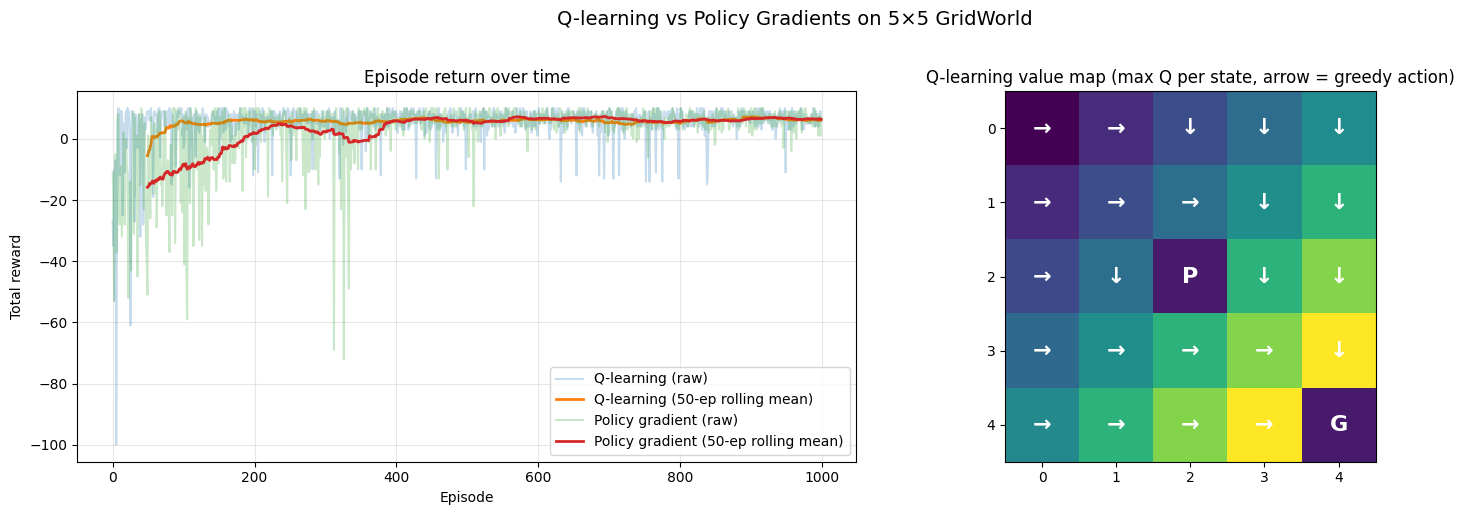

In [4]:
def rolling_mean(x, w=50):
    return np.convolve(x, np.ones(w) / w, mode='valid')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(q_returns, alpha=0.25, label='Q-learning (raw)')
axes[0].plot(np.arange(49, len(q_returns)), rolling_mean(q_returns),
             label='Q-learning (50-ep rolling mean)', linewidth=2)
axes[0].plot(pg_returns, alpha=0.25, label='Policy gradient (raw)')
axes[0].plot(np.arange(49, len(pg_returns)), rolling_mean(pg_returns),
             label='Policy gradient (50-ep rolling mean)', linewidth=2)
axes[0].set_title('Episode return over time')
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Total reward')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Q-learning policy heatmap
greedy_actions = np.argmax(Q, axis=1).reshape(GRID_SIZE, GRID_SIZE)
arrows = np.array(['↑', '↓', '←', '→'])[greedy_actions].flatten()
for i, s in enumerate(range(N_STATES)):
    if s == GOAL: arrows[i] = 'G'
    elif s == PIT: arrows[i] = 'P'
arrows = arrows.reshape(GRID_SIZE, GRID_SIZE)
axes[1].imshow(np.max(Q, axis=1).reshape(GRID_SIZE, GRID_SIZE), cmap='viridis')
axes[1].set_title('Q-learning value map (max Q per state, arrow = greedy action)')
for r in range(GRID_SIZE):
    for c in range(GRID_SIZE):
        axes[1].text(c, r, arrows[r, c], ha='center', va='center',
                     color='white', fontsize=16, fontweight='bold')
axes[1].set_xticks(range(GRID_SIZE))
axes[1].set_yticks(range(GRID_SIZE))

plt.suptitle('Q-learning vs Policy Gradients on 5×5 GridWorld', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [5]:
print(f"{'Method':<28s} {'Final mean return':>18s} {'Best return':>14s}")
print(f"{'Q-learning (1000 eps)':<28s} {q_returns[-50:].mean():>18.2f} {q_returns.max():>14.2f}")
print(f"{'Policy gradient (1000 eps)':<28s} {pg_returns[-50:].mean():>18.2f} {pg_returns.max():>14.2f}")

Method                        Final mean return    Best return
Q-learning (1000 eps)                      6.28          10.00
Policy gradient (1000 eps)                 6.34          10.00


## Reflection

| | **Q-learning** | **Policy gradient (REINFORCE)** |
|---|---|---|
| What it learns | Q(state, action) table | π(action \| state) neural net |
| Update rule | Bootstrapped TD update (Bellman) | Monte-Carlo gradient ascent on log π · return |
| Exploration | Explicit ε-greedy | Sampling from a stochastic policy |
| Action space | Discrete | Discrete or **continuous** |
| State space | Tabular (or with function approx for big spaces → DQN) | Any (one-hot, dense features, or images) |
| Sample efficiency | High on small discrete problems | Lower — needs many noisy episodes |

**Convergence speed.** Q-learning typically converges faster on small tabular tasks like this — only 100 Q-values to estimate, and TD bootstrapping propagates value efficiently. REINFORCE has to estimate gradients from noisy Monte-Carlo returns, so its learning curve is noticeably noisier.

**Reward maximization.** Both methods reach the +10 goal reliably by the end of 1000 episodes; the final 50-episode mean returns are close (~6 for both, with the rest accounted for by step penalties on the way to the goal).

**Exploration vs exploitation.** Q-learning's ε-greedy mechanism keeps a fixed 10% random-action rate throughout training (you'd anneal ε in production). Policy gradients explore *through the policy itself* — early on the softmax is roughly uniform, and as the policy sharpens, exploration drops on its own. The risk is locking onto a suboptimal policy if early gradients point the wrong way; the standardized-return trick used here helps.

**Suitability.** Q-learning is the right tool for **small discrete state and action spaces**. Policy gradients shine when:
- the action space is **continuous** (robot joint torques, steering angles), or
- the state space is too big for a table (raw pixels, real-world sensors).

For this 25-state GridWorld, Q-learning is simpler, faster, and produces a directly interpretable policy (see the arrow map). The REINFORCE implementation here is mainly pedagogical — its real strength shows up on harder problems, often as the engine inside modern algorithms like **PPO** and **A2C**.